# Partie 1 -  Pipeline de détection

## 1 - Données

### 1.1 Réorganisation du dataset

In [1]:
# Importation des bibliothèques nécessaires
import os, shutil
from pathlib import Path
import random
from collections import Counter
import matplotlib.pyplot as plt
import cv2
import numpy as np
from ultralytics import YOLO


In [2]:
# Création de la structure nécessaire pour le modèle YOLO
os.makedirs("dataset_yolo", exist_ok=True)
os.makedirs("dataset_yolo/images/train", exist_ok=True)
os.makedirs("dataset_yolo/images/val", exist_ok=True)
os.makedirs("dataset_yolo/images/test", exist_ok=True)
os.makedirs("dataset_yolo/labels/train", exist_ok=True)
os.makedirs("dataset_yolo/labels/val", exist_ok=True)
os.makedirs("dataset_yolo/labels/test", exist_ok=True)

print("Création des dossiers terminée")

with open("./dataset_kaggle/train_files.txt") as f:
    train_files = f.read().splitlines()

with open("./dataset_kaggle/val_files.txt") as f:
    val_files = f.read().splitlines()

# Le dataset ne contient pas de jeu de test. A nous de le créer.
random.seed(42)
random.shuffle(train_files)

n_test = int(len(train_files) * 0.10)
test_files = train_files[:n_test]
train_files = train_files[n_test:]

# Copie des images et labels vers les bons dossiers pour le modèle YOLO
for img in test_files:
    p = Path(img)
    img_source = Path(f"./dataset_kaggle/images/{img}")
    label_source = Path(f"./dataset_kaggle/labels/{p.stem}.txt")
    shutil.copy2(img_source, Path(f"./dataset_yolo/images/test/{img}"))
    shutil.copy2(label_source, Path(f"./dataset_yolo/labels/test/{p.stem}.txt"))

for img in train_files:
    p = Path(img)
    img_source = Path(f"./dataset_kaggle/images/{img}")
    label_source = Path(f"./dataset_kaggle/labels/{p.stem}.txt")
    shutil.copy2(img_source, Path(f"./dataset_yolo/images/train/{img}"))
    shutil.copy2(label_source, Path(f"./dataset_yolo/labels/train/{p.stem}.txt"))

for img in val_files:
    p = Path(img)
    img_source = Path(f"./dataset_kaggle/images/{img}")
    label_source = Path(f"./dataset_kaggle/labels/{p.stem}.txt")
    shutil.copy2(img_source, Path(f"./dataset_yolo/images/val/{img}"))
    shutil.copy2(label_source, Path(f"./dataset_yolo/labels/val/{p.stem}.txt"))

print("Copie des images/labels terminés")
for split in ["train", "val", "test"]:
    n_img = len(os.listdir(f"dataset_yolo/images/{split}"))
    n_lbl = len(os.listdir(f"dataset_yolo/labels/{split}"))
    print(f"{split}: {n_img} images, {n_lbl} labels")

# Création du fichier YAML nécesaire à YOLO
dataset_path = Path("dataset_yolo").resolve()

yaml_content = f"""path: {dataset_path}
train: images/train
val: images/val
test: images/test

# Classes
names:
  0: person
  1: ear
  2: ear-mufs
  3: face
  4: face-guard
  5: face-mask
  6: foot
  7: tool
  8: glasses
  9: gloves
  10: helmet
  11: hands
  12: head
  13: medical-suit
  14: shoes
  15: safety-suit
  16: safety-vest
"""

with open("sh17.yaml", "w") as f:
    f.write(yaml_content)

print("Fichier yaml créé.")

Création des dossiers terminée
Copie des images/labels terminés
train: 5832 images, 5832 labels
val: 1620 images, 1620 labels
test: 647 images, 647 labels
Fichier yaml créé.


### 1.2 Exploration et statistiques

Distribution des instances par classe (histogramme commenté)

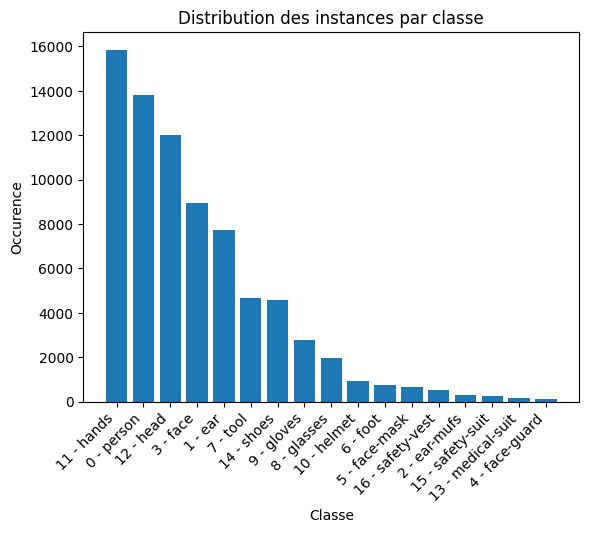

In [3]:
# Rappel du TP 9 : les fichiers labels commencent par l'identifiant de la classe, puis les coordonnées de la bounding box.
# On parcourt donc tous les fichiers et on récupère la classe.

repartition_classes = Counter()
for split in ["train", "val", "test"]:
    label_dir = Path(f"dataset_yolo/labels/{split}")
    
    for txt_file in label_dir.iterdir():
        with open(txt_file) as f:
            lignes = f.read().splitlines()
            for ligne in lignes:
                classe = ligne.split()[0]
                repartition_classes[classe] += 1

noms_classes = {
    "0": "person",
    "1": "ear",
    "2": "ear-mufs",
    "3": "face",
    "4": "face-guard",
    "5": "face-mask",
    "6": "foot",
    "7": "tool",
    "8": "glasses",
    "9": "gloves",
    "10": "helmet",
    "11": "hands",
    "12": "head",
    "13": "medical-suit",
    "14": "shoes",
    "15": "safety-suit",
    "16": "safety-vest",
}

classes, occurrences = zip(*repartition_classes.most_common())
labels = [f"{id_classe} - {noms_classes[id_classe]}" for id_classe in classes]

# Histogramme avec matplotlib
plt.title("Distribution des instances par classe")
plt.xlabel("Classe")
plt.ylabel("Occurence")
plt.xticks(rotation=45, ha="right")
plt.bar(labels, occurrences)
plt.show()

## COMMENTAIRE ##
# On voit une répartition très inégale des classes.
# Les parties du corps humains (hands, person, head et ear) sont largement surreprésentées.
# Ce qu'on cherche pour ce TP (helmet, safety-vest etc...) sont quant à eux très sous-représentées
# Le modèle aura donc du mal à les repérer




Ratio  entre  la  classe  majoritaire  et  la  classe  minoritaire,  discuter  l'impact  potentiel  sur 
l'entraînement

In [4]:
# D'après l'histogramme, la classe majoritaire est la 11 et la minoritaire est la 4
classe_majoritaire = repartition_classes.get('11')
classe_minoritaire = repartition_classes.get('4')

ratio = classe_majoritaire / classe_minoritaire

print(f"ratio : {ratio}")

# COMMENTAIRE ###
# La classe majoritaire est représenté 118 fois de plus que la classe minoritaire.
# Comme vu dans le graphique et mis en commentaire plus haut, le dataset est très déséquilibré.
# Le modèle aura du mal à apprendre concernant les objectifs de repérage des EPI.


ratio : 118.28358208955224


Visualisation d'exemples annotés pour les trois splits (train, val, test)

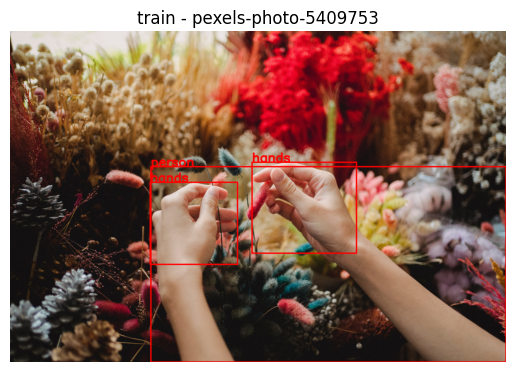

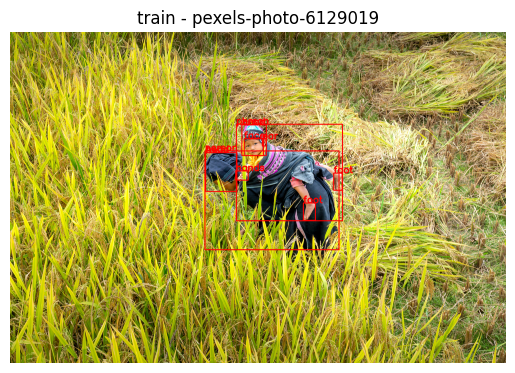

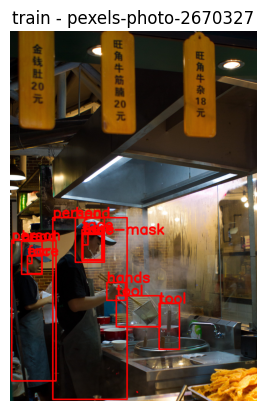

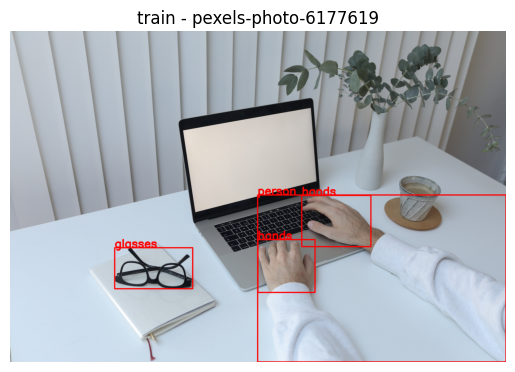

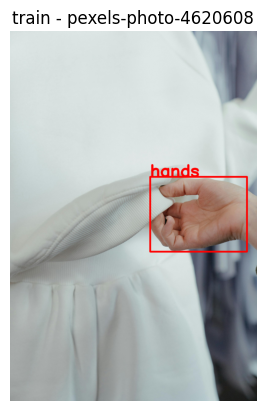

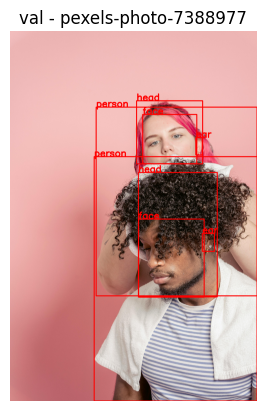

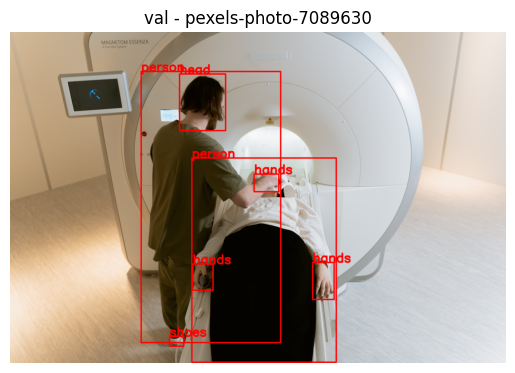

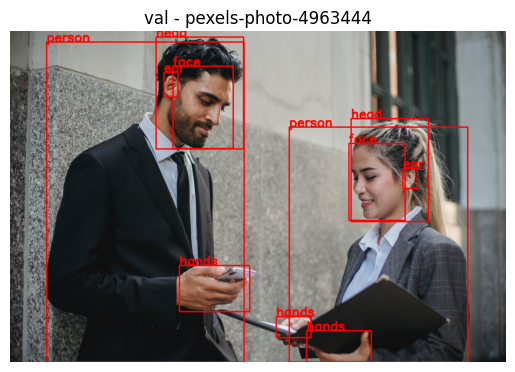

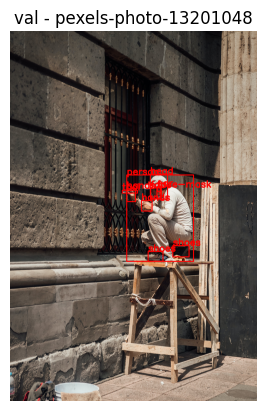

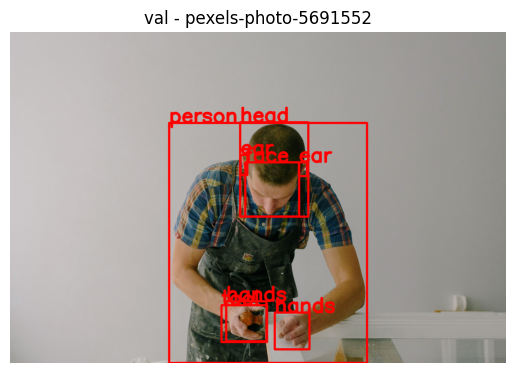

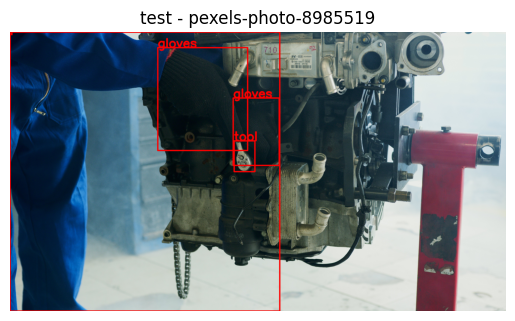

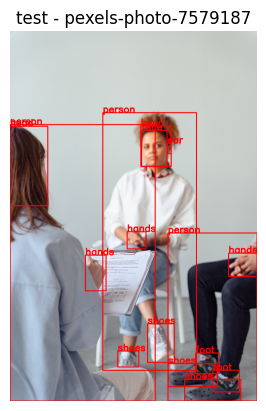

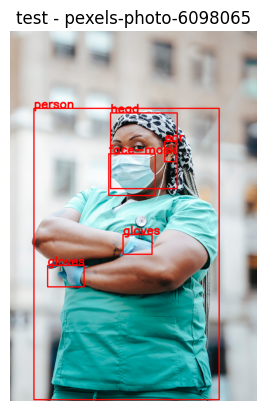

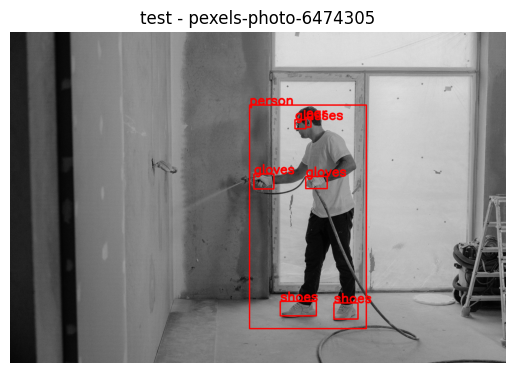

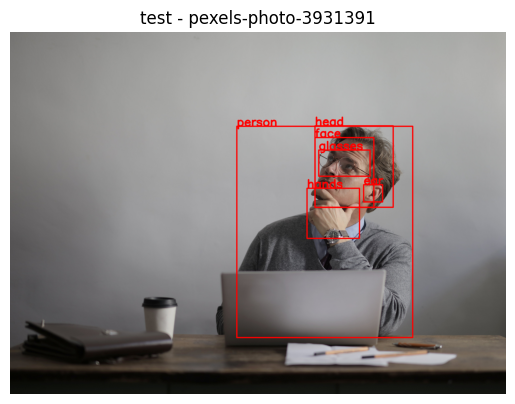

In [5]:
# Fonction permettant de lire et d'annoter les labels sur les images
def annoter_image(img, image_dimensions, file_name, split_name):
    hauteur_img = image_dimensions[0]
    largeur_img = image_dimensions[1]
    with open(f"./dataset_yolo/labels/{split_name}/{file_name}.txt") as f:
        lignes = f.read().splitlines()
        for ligne in lignes:
            classe = ligne.split()[0]
            x_centre = float(ligne.split()[1])
            y_centre = float(ligne.split()[2])
            largeur = float(ligne.split()[3])
            hauteur = float(ligne.split()[4])
            x_centre_px = x_centre * largeur_img
            y_centre_px = y_centre * hauteur_img
            largeur_px = largeur * largeur_img
            hauteur_px = hauteur * hauteur_img
            x1 = x_centre_px - largeur_px / 2
            y1 = y_centre_px - hauteur_px / 2
            x2 = x_centre_px + largeur_px / 2
            y2 = y_centre_px + hauteur_px / 2
            cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 15)
            cv2.putText(img, str(noms_classes[classe]), (int(x1), int(y1) - 5), cv2.FONT_HERSHEY_SIMPLEX, 5, (0, 0, 255), 20)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Affichage des 5 premières images de chaque dossier
for split in ["train", "val", "test"]:
    label_dir = Path(f"dataset_yolo/images/{split}")
    files = list(label_dir.iterdir())[:5]
    for col in range(5):
        img_path = files[col]
        img = cv2.imread(str(img_path))
        img_annotee = annoter_image(
            img,
            img.shape,
            img_path.stem,
            split
        )
        plt.imshow(img_annotee)
        plt.title(f"{split} - {img_path.stem}")
        plt.axis("off")
        plt.show()

Statistiques sur les tailles des bounding boxes (petites, moyennes, grandes)

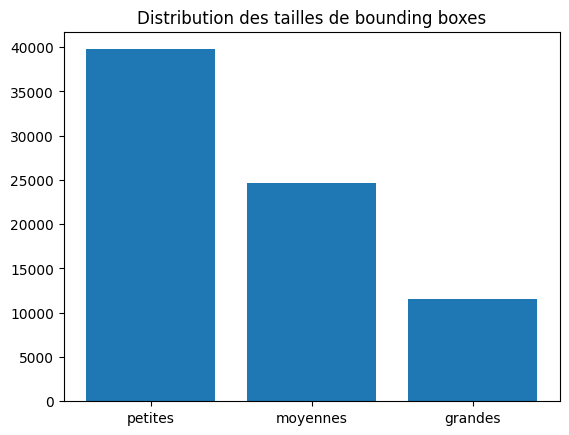

In [6]:
# Récupération de l'air de toutes les boudings boxs
liste_aires = []
for split in ["train", "val", "test"]:
    label_dir = Path(f"dataset_yolo/labels/{split}")
    
    for txt_file in label_dir.iterdir():
        with open(txt_file) as f:
            lignes = f.read().splitlines()
            for ligne in lignes:
                largeur = ligne.split()[3]
                hauteur = ligne.split()[4]
                aire = float(hauteur) * float(largeur)
                liste_aires.append(aire)

# Arbitrairement, je dis qu'une petite taille est à 1 % et moyenne 10 % (recherche internet)
frontiere_petite_taille, frontiere_grande_taille = 0.01, 0.1

# Je repasse dans la liste_aires pour classifier les boudings boxes
petites_tailles = 0
moyennes_tailles = 0
grandes_tailles = 0
for aire in liste_aires:
    if aire <= frontiere_petite_taille:
        petites_tailles += 1
    elif aire >= frontiere_grande_taille:
        grandes_tailles += 1
    else:
        moyennes_tailles += 1

plt.bar(["petites", "moyennes", "grandes"], [petites_tailles, moyennes_tailles, grandes_tailles])
plt.title("Distribution des tailles de bounding boxes")
plt.show()

## COMMENTAIRE ##

# On voit qu'il y a énormément de petites boxes/ Le modèle aura des difficultés à les détecter.
# Il faudra certainement les recadrer.


### 1.3 Pré-traitement 

Redimensionnement des images à la résolution d'entrée du modèle choisi

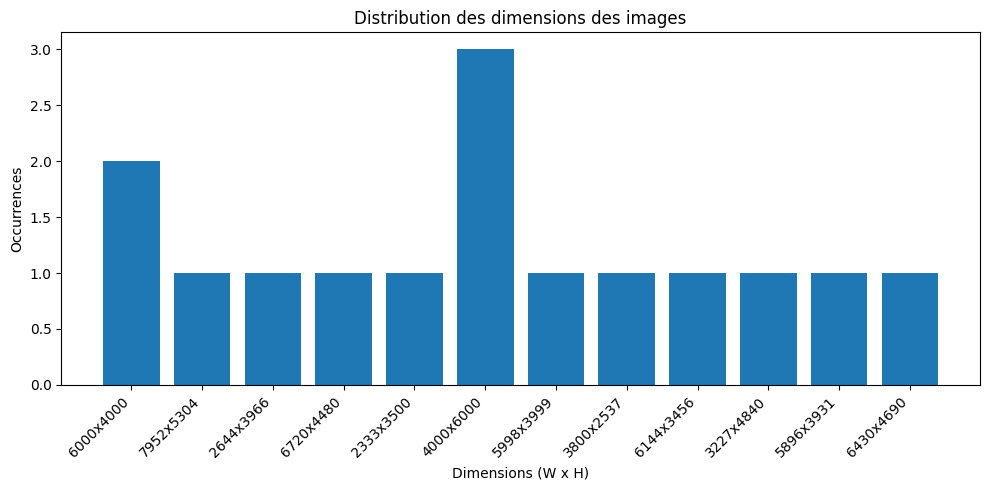

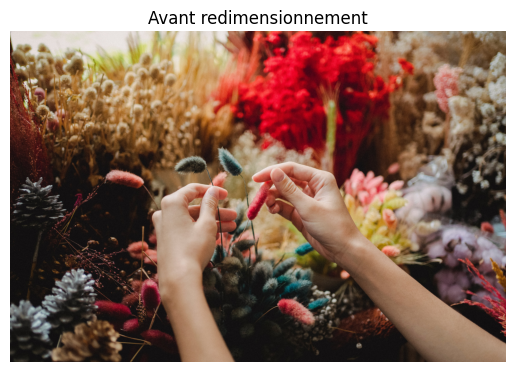

Dimensions après redimensionnement : (640, 640, 3)


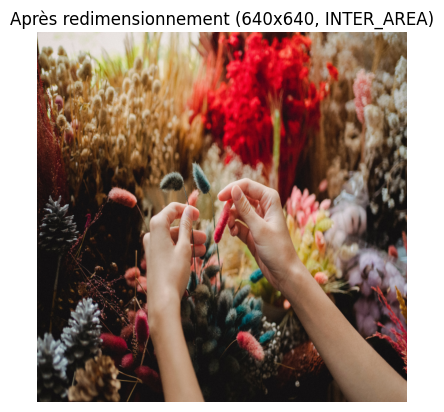

In [7]:
# Vérification des dimensions des photos

dimensions = Counter()
for split in ["train", "val", "test"]:
    image_dir = Path(f"dataset_yolo/images/{split}")
    files = list(image_dir.iterdir())

    for img_path in files[:5]:
        img = cv2.imread(str(img_path))
        h, w = img.shape[:2]
        dimensions[(w, h)] += 1

labels = [f"{w}x{h}" for (w, h) in dimensions.keys()]
values = list(dimensions.values())

plt.figure(figsize=(10, 5))
plt.title("Distribution des dimensions des images")
plt.xlabel("Dimensions (W x H)")
plt.ylabel("Occurrences")
plt.xticks(rotation=45, ha="right")
plt.bar(labels, values)
plt.tight_layout()
plt.show()

# Au vu des différentes résolutions, il faut redimensionner les images en 640*640.
# Inter-area est préconisé dans la doc de YOLO pour une "grande réduction". Ici on passe de 4000* ou 6000* à 640*
# Exemple sur une photo pour l'exemple. On l'appliquera au dataset pour l'entrainement plus tard. 
# A savoir que ceci n'est qu'une exemple et ce n'est pas nous qui allons le faire sur tout le dataset mais le composant YOLO avec imgsz=640 
image_dir = Path("dataset_yolo/images/train")
files = list(image_dir.iterdir())
img_path = files[0]
img_original = cv2.imread(str(img_path))

plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title("Avant redimensionnement")
plt.axis("off")
plt.show()

# Redimensionnement
img_redim = cv2.resize(img_original, (640, 640), interpolation=cv2.INTER_AREA)
print(f"Dimensions après redimensionnement : {img_redim.shape}")
plt.imshow(cv2.cvtColor(img_redim, cv2.COLOR_BGR2RGB))
plt.title("Après redimensionnement (640x640, INTER_AREA)")
plt.axis("off")
plt.show()

Normalisation des valeurs de pixels

In [8]:
# Une image pour un exemple
img_path = files[0]
img = cv2.imread(str(img_path))

# Etat "brute" de l'image
print(f"Avant normalisation -> dtype : {img.dtype}, range : [{img.min()}, {img.max()}]")

# Normalisation manuelle
img_normalisee = img / 255.0

# Etat après normalisation
print(f"Après normalisation  -> dtype : {img_normalisee.dtype}, range : [{img_normalisee.min()}, {img_normalisee.max()}]")

# Même remarque en en haut. Ceci est un exemple mais le composant YOLO fera l'affaire


Avant normalisation -> dtype : uint8, range : [0, 255]
Après normalisation  -> dtype : float64, range : [0.0, 1.0]


Débruitage si des artefacts sont constatés

In [9]:
# Rien à faire. Je n'ai pas vu d'artefact sur l'etape de visualisation
# Il s'agit aussi d'un dataset tres propre

Recadrage (crop) pour les objets de très petite taille

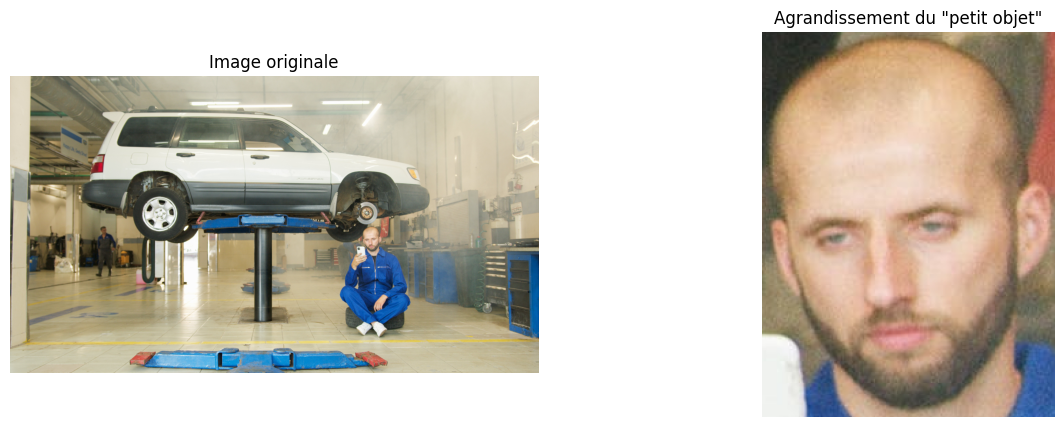

In [10]:
# Comme vu au dessus, il y a beaucoup d'objets de petites tailles et il est important de les augmenter pour que el modèle puisse les reconnaître.
# ici je mettrai qu'un exemple. On fera le travail dans le pipeline plus tard

# Fonction permettant de chercher un petit objet dans un photo pour l'exemple
def chercher_petit_objet():
    for split in ["train", "val", "test"]:
        label_dir = Path(f"dataset_yolo/labels/{split}")
        image_dir = Path(f"dataset_yolo/images/{split}")

        for txt_file in label_dir.iterdir():
            with open(txt_file) as f:
                lignes = f.read().splitlines()
                for ligne in lignes:
                    largeur = float(ligne.split()[3])
                    hauteur = float(ligne.split()[4])
                    aire = largeur * hauteur

                    if aire <= frontiere_petite_taille:
                        matches = list(image_dir.glob(f"{txt_file.stem}.*"))

                        if not matches:
                            continue

                        img_path = str(matches[0])

                        return (
                            img_path,
                            float(ligne.split()[1]),
                            float(ligne.split()[2]),
                            largeur,
                            hauteur,
                        )

# Déroulé pour agrandir le petit objet
img_path, x_centre, y_centre, largeur, hauteur = chercher_petit_objet()
img = cv2.imread(img_path)

largeur_image = float(img.shape[1])
hauteur_image = float(img.shape[0])
x_centre_px = x_centre * largeur_image
y_centre_px = y_centre * hauteur_image
largeur_px = largeur * largeur_image
hauteur_px = hauteur * hauteur_image
x1 = x_centre_px - largeur_px / 2
y1 = y_centre_px - hauteur_px / 2
x2 = x_centre_px + largeur_px / 2
y2 = y_centre_px + hauteur_px / 2
visage = img[int(y1):int(y2), int(x1):int(x2)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title('Image originale'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(visage, cv2.COLOR_BGR2RGB)); axes[1].set_title('Agrandissement du "petit objet"'); axes[1].axis('off')
plt.show()

## COMMENTAIRE ##
# On voit qu'on peut bien isoler et agrandir un petit objet pour que le modèle le détecte mieux.

                    

### 1.4 Augmentation des données 

Variations d'éclairage (contre-jour, nuit, éblouissement)

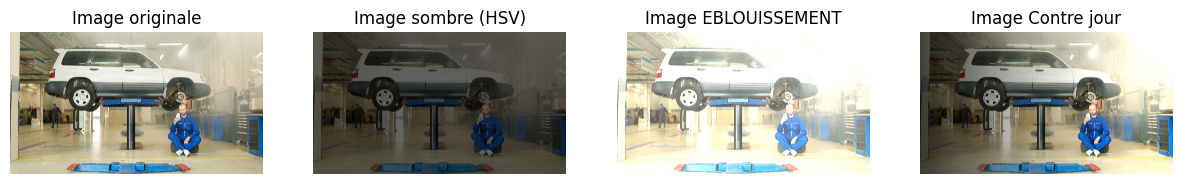

In [11]:
# 1 - ASSOMBRISSEMENT (NUIT):  Reprenons l'image précédente et ajoutons un effet "nuit" comme vu dans le TP 0

img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
img_hsv[:, :, 2] = (img_hsv[:, :, 2] * 0.4).astype(np.uint8)
img_sombre = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2BGR)

# 2 - EBLOUISSEMENT

img_copy = img.astype(float)
img_eblouissement = np.clip(img.astype(float) + 80 , 0, 255).astype(np.uint8)

# 3 - Contre jour (aide par IA)

h, w = img.shape[:2]

gradient = np.tile(
    np.linspace(0.3, 1.5, w, dtype=np.float32),
    (h, 1)
)

img_contrejour = img.astype(np.float32)

for c in range(3):
    img_contrejour[:, :, c] *= gradient

img_contrejour = np.clip(img_contrejour, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Image originale")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(img_sombre, cv2.COLOR_BGR2RGB))
axes[1].set_title("Image sombre (HSV)")
axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(img_eblouissement, cv2.COLOR_BGR2RGB))
axes[2].set_title("Image EBLOUISSEMENT")
axes[2].axis("off")
axes[3].imshow(cv2.cvtColor(img_contrejour, cv2.COLOR_BGR2RGB))
axes[3].set_title("Image Contre jour")
axes[3].axis("off")
plt.show()



Changements d'angle de vue (vue plongeante, profil) 


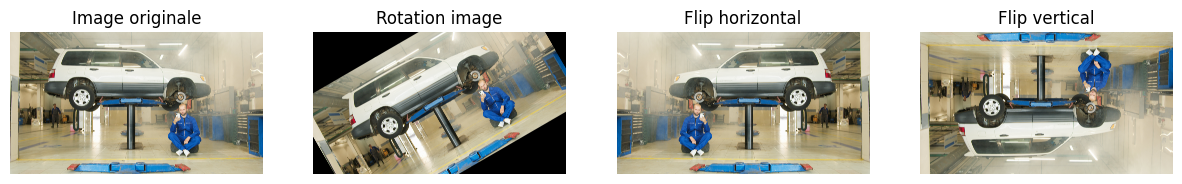

In [12]:
# Comme vu dans le TP 0, on rotate et flip les images

H, L = img.shape[:2]
centre = (L // 2, H // 2)

matrice = cv2.getRotationMatrix2D(center=centre, angle=30, scale=1)
img_rot = cv2.warpAffine(src=img, M=matrice, dsize=(L, H))

img_flip_h = cv2.flip(src=img, flipCode=1)
img_flip_v = cv2.flip(src=img, flipCode=0)

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB));  axes[0].set_title('Image originale'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_rot, cv2.COLOR_BGR2RGB)); axes[1].set_title('Rotation image');    axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(img_flip_h, cv2.COLOR_BGR2RGB)); axes[2].set_title('Flip horizontal'); axes[2].axis('off')
axes[3].imshow(cv2.cvtColor(img_flip_v, cv2.COLOR_BGR2RGB)); axes[3].set_title('Flip vertical'); axes[3].axis('off')
plt.show()

Occlusions partielles fréquentes sur les chantiers

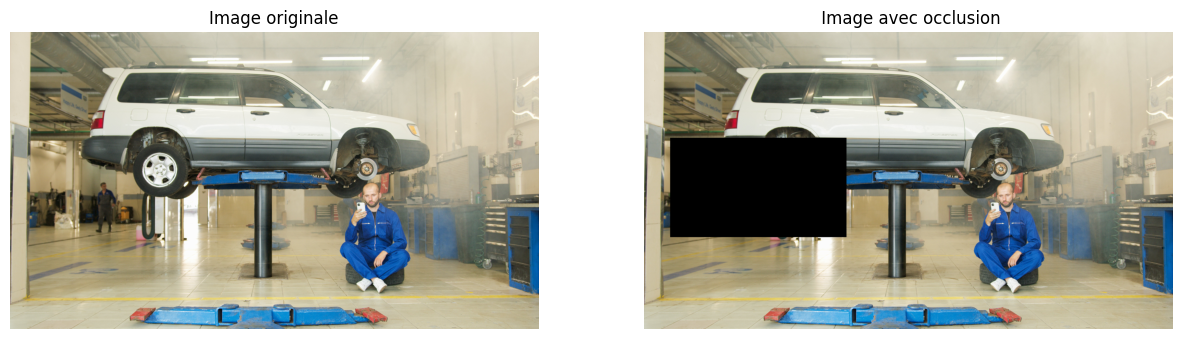

In [13]:
# On pose un rectangle noir aléatoirement sur l'image

img_occlusion = img.copy()

x1 = np.random.randint(0, w - w // 3)
y1 = np.random.randint(0, h - h // 3)

x2 = x1 + w // 3
y2 = y1 + h // 3

cv2.rectangle(img_occlusion, (x1, y1), (x2, y2), (0, 0, 0), -1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title('Image originale'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_occlusion, cv2.COLOR_BGR2RGB)); axes[1].set_title(' Image avec occlusion'); axes[1].axis('off')
plt.show()

 ## 2 - Choix et configuration du modèle 

### 2.1 Choix du modèle

Au vu du projet, j'opterai pour YOLO car il permet une détection en temps réel (un seul passage), contrairement à Faster R-CNN qui est lui en deux etapes mais plus lent. Il est également léger et facile à fine-tuner, ce qui convient bien à notre dataset desequilibre (vu en 1.2). Enfin, ce choix est cohérent avec l'exigence du projet de traiter des flux videos en direct

### 2.2 Configuration, entraînement et regularisation

In [19]:
model = YOLO("yolo26n.pt")

results = model.train(
    data="sh17.yaml",
    epochs=20,
    batch=16,
    imgsz=640,
    patience=10,
    freeze=10,
    fliplr=0.5,
    hsv_v=0.5,
)

New https://pypi.org/project/ultralytics/8.4.62 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.61 🚀 Python-3.12.0 torch-2.12.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=sh17.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimi

 ## 3 - Évaluation

mAP@50 et mAP@50-95

In [20]:
metrics = model.val(data="sh17.yaml", split='test')

print(metrics.box.map50)
print(metrics.box.map)

Ultralytics 8.4.61 🚀 Python-3.12.0 torch-2.12.0 CPU (Apple M4)
YOLO26n summary (fused): 122 layers, 2,378,151 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1827.6±357.3 MB/s, size: 2167.0 KB)
val: Scanning /Users/ecole18.06-t.m.t/Desktop/COMPUTER VISION/projet/dataset_yolo/labels/test.cache... 647 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 647/647 678.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 2.3s/it 1:352.2sss
                   all        647       5605      0.472      0.391      0.406      0.247
                person        599        988      0.808      0.884        0.9      0.718
                   ear        373        569      0.681      0.631      0.656      0.353
              ear-mufs         17         25          0          0     0.0131    0.00388
                  face        429        667      0.743      0.802      0.836      0.591
       

Précision et rappel

Classe person : Précision = 0.8077230776698016 - Rappel = 0.8843858806245234
Classe ear : Précision = 0.6814796177389252 - Rappel = 0.6309314586994728
Classe ear-mufs : Précision = 0.0 - Rappel = 0.0
Classe face : Précision = 0.7433844507286098 - Rappel = 0.8020989505247377
Classe face-guard : Précision = 0.413681709530027 - Rappel = 0.12350752143168016
Classe face-mask : Précision = 0.4707979491348436 - Rappel = 0.32653061224489793
Classe foot : Précision = 0.2132993753566549 - Rappel = 0.017241379310344827
Classe tool : Précision = 0.4774807223136101 - Rappel = 0.2073170731707317
Classe glasses : Précision = 0.4756235568513555 - Rappel = 0.23025305665766774
Classe gloves : Précision = 0.5731417947351753 - Rappel = 0.393449456349832
Classe helmet : Précision = 0.5062172856271823 - Rappel = 0.4696969696969697
Classe hands : Précision = 0.7304278017595396 - Rappel = 0.6925704526046115
Classe head : Précision = 0.8149933730285608 - Rappel = 0.8680800942285041
Classe medical-suit : Précis

/var/folders/9c/5j3r976n0dx99snpqd2skv4h0000gp/T/ipykernel_73635/260597768.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(classes, rotation=45, ha="right")
/var/folders/9c/5j3r976n0dx99snpqd2skv4h0000gp/T/ipykernel_73635/260597768.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(classes, rotation=45, ha="right")


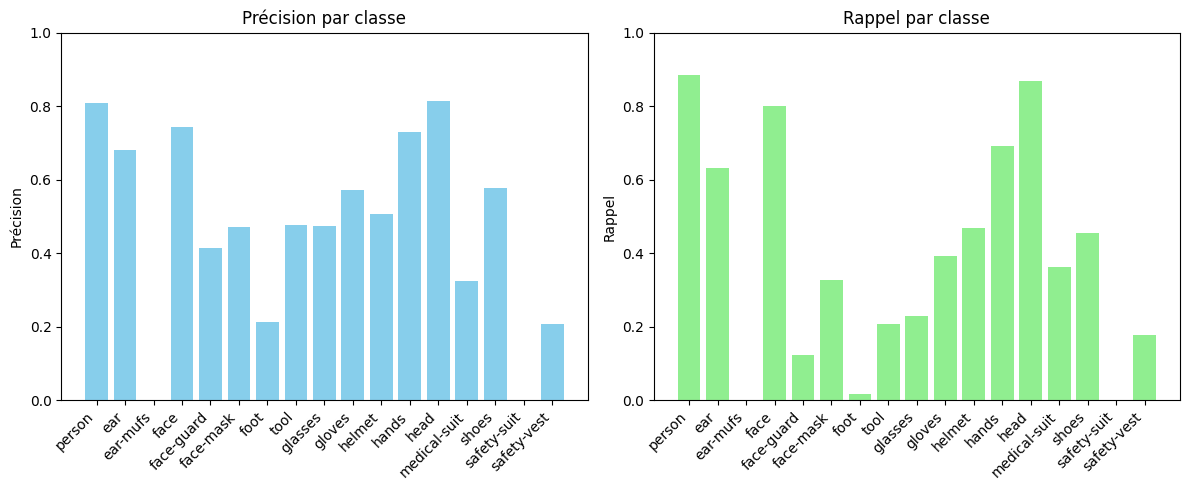

In [43]:
for i, classe in metrics.names.items():
    print(f"Classe {classe} : Précision = {metrics.box.p[i]} - Rappel = {metrics.box.r[i]}")

classes = list(metrics.names.values())
precision = metrics.box.p
rappel = metrics.box.r

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Précision
axes[0].bar(classes, precision, color="skyblue")
axes[0].set_title("Précision par classe")
axes[0].set_ylabel("Précision")
axes[0].set_ylim(0, 1)

# Rappel
axes[1].bar(classes, rappel, color="lightgreen")
axes[1].set_title("Rappel par classe")
axes[1].set_ylabel("Rappel")
axes[1].set_ylim(0, 1)

axes[0].set_xticklabels(classes, rotation=45, ha="right")
axes[1].set_xticklabels(classes, rotation=45, ha="right")

plt.tight_layout()
plt.show()

## COMMENTAIRE ##
# Dans notre projet, la métrique du rappel est plus adaptée que la précision,
# car il est plus important de minimiser les faux négatifs (ne pas manquer un
# travailleur non conforme) que d'éviter les faux positifs (fausses alertes).

F1-score par classe 

Classe person : F1-score = 0.844
Classe ear : F1-score = 0.655
Classe ear-mufs : F1-score = nan
Classe face : F1-score = 0.772
Classe face-guard : F1-score = 0.190
Classe face-mask : F1-score = 0.386
Classe foot : F1-score = 0.032
Classe tool : F1-score = 0.289
Classe glasses : F1-score = 0.310
Classe gloves : F1-score = 0.467
Classe helmet : F1-score = 0.487
Classe hands : F1-score = 0.711
Classe head : F1-score = 0.841
Classe medical-suit : F1-score = 0.344
Classe shoes : F1-score = 0.510
Classe safety-suit : F1-score = nan
Classe safety-vest : F1-score = 0.191


/var/folders/9c/5j3r976n0dx99snpqd2skv4h0000gp/T/ipykernel_73635/2668352493.py:1: RuntimeWarning: invalid value encountered in divide
  f1 = 2 * (precision * rappel) / (precision + rappel)


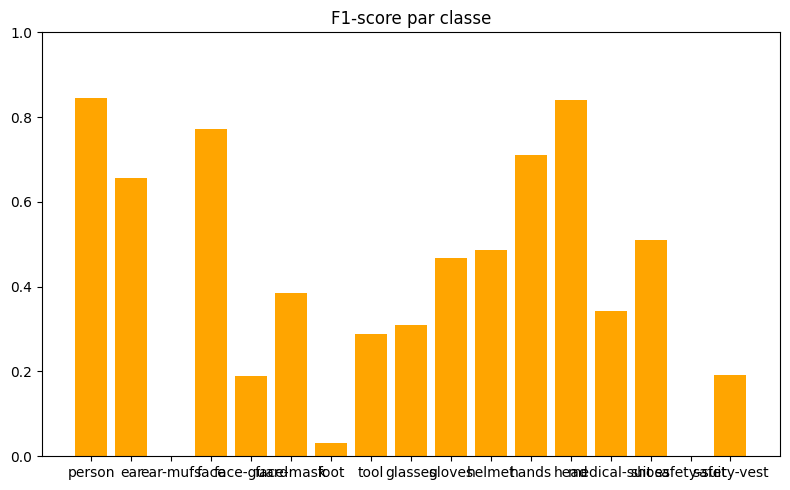

In [ ]:
f1 = 2 * (precision * rappel) / (precision + rappel)

for i, classe in metrics.names.items():
    print(f"Classe {classe} : F1-score = {f1[i]:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(classes, f1, color="orange")
ax.set_title("F1-score par classe")
ax.set_ylim(0, 1)

ax.set_xticklabels(classes, rotation=45, ha="right")


plt.tight_layout()
plt.show()

## 4 - Inférence

Sur une image

In [30]:

model = YOLO("runs/detect/train/weights/best.pt")
print(os.listdir("dataset_yolo/images/test")[:5])

# Couples (zone corps -> EPI requis)
CHECKS = {
    12: 10,  # head -> helmet
    11: 9,   # hands -> gloves
    3: 8,    # face -> glasses
    0: 16,   # person -> safety-vest
}

img_path = "dataset_yolo/images/test/pexels-photo-7579187.jpeg"
img = cv2.imread(str(img_path))

results = model.predict(img, conf=0.25)[0]
classes_detectees = results.boxes.cls.tolist() if results.boxes is not None else []

non_conforme = any(
    body in classes_detectees and ppe not in classes_detectees
    for body, ppe in CHECKS.items()
)

img_annotee = results.plot()

if non_conforme:
    h, w = img_annotee.shape[:2]
    bandeau_h = 150  # hauteur du bandeau (était 80) — plus grand = bande plus haute

    cv2.rectangle(img_annotee, (0, h - bandeau_h), (w, h), (0, 0, 255), -1)

    cv2.putText(img_annotee, "NON CONFORME - EPI MANQUANT", (10, h - 50),
                cv2.FONT_HERSHEY_SIMPLEX, 2.5, (255, 255, 255), 5)


cv2.imwrite("test_image_sortie.jpg", img_annotee)

['pexels-photo-8985519.jpeg', 'pexels-photo-7579187.jpeg', 'pexels-photo-6098065.jpeg', 'pexels-photo-6474305.jpeg', 'pexels-photo-3931391.jpeg']

0: 640x448 3 persons, 1 ear, 2 faces, 2 handss, 2 heads, 5 shoess, 30.3ms
Speed: 1.5ms preprocess, 30.3ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 448)


True

Pour une video

In [41]:
cap = cv2.VideoCapture("video_test.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("video_annotee.mp4", fourcc, fps, (w, h))

nb_non_conforme = 0
nb_frames = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    nb_frames += 1

    results = model.predict(frame, conf=0.25, verbose=False)[0]
    classes_detectees = results.boxes.cls.tolist() if results.boxes is not None else []

    non_conforme = any(
        body in classes_detectees and ppe not in classes_detectees
        for body, ppe in CHECKS.items()
    )

    if non_conforme:
        nb_non_conforme += 1
        bandeau_h = 150
        cv2.rectangle(frame, (0, h - bandeau_h), (w, h), (0, 0, 255), -1)
        cv2.putText(frame, "NON CONFORME - EPI MANQUANT", (10, h - 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.5, (255, 255, 255), 5)

    frame_annotee = results.plot(img=frame)
    out.write(frame_annotee)
 
cap.release()
out.release()

print(f"{nb_non_conforme} / {nb_frames} frames non conformes")
print("Vidéo sauvegardée !")

17241 / 28156 frames non conformes
Vidéo sauvegardée !


Au vu du résultat , je vais m'amuser en ne mettant que head -> helmet et person -> safety vest qui eux sont mieux détectés

In [ ]:
CHECKS_EPI = {
    12: 10,  # head -> helmet
    0: 16,   # person -> safety-vest
}

cap = cv2.VideoCapture("video_test.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("video_annotee_epi.mp4", fourcc, fps, (w, h))

nb_non_conforme = 0
nb_frames = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    nb_frames += 1

    results = model.predict(frame, conf=0.25, verbose=False)[0]
    classes_detectees = results.boxes.cls.tolist() if results.boxes is not None else []

    non_conforme = any(
        body in classes_detectees and ppe not in classes_detectees
        for body, ppe in CHECKS_EPI.items()
    )

    if non_conforme:
        nb_non_conforme += 1
        bandeau_h = 150
        cv2.rectangle(frame, (0, h - bandeau_h), (w, h), (0, 0, 255), -1)
        cv2.putText(frame, "NON CONFORME - EPI MANQUANT", (10, h - 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.5, (255, 255, 255), 5)

    frame_annotee = results.plot(img=frame)
    out.write(frame_annotee)
 
cap.release()
out.release()

print(f"{nb_non_conforme} / {nb_frames} frames non conformes")
print("Vidéo sauvegardée !")

17241 / 28156 frames non conformes
Vidéo sauvegardée !


# Partie 2 : Analyse avancée et déploiement

## Axe B : Focus classes EPI 

Créer le dataset filtré 

In [38]:
# Remappage : helmet(10)->0, head(12)->1, safety-vest(16)->2
REMAP = {10: 0, 12: 1, 16: 2}

# Copie des images
for split in ["train", "val", "test"]:
    os.makedirs(f"dataset_yolo_epi/images/{split}", exist_ok=True)
    os.makedirs(f"dataset_yolo_epi/labels/{split}", exist_ok=True)

# On labelise que que les helmets , heads et safety-vest
for split in ["train", "val", "test"]:
    for img_path in Path(f"dataset_yolo/images/{split}").iterdir():
        shutil.copy2(img_path, f"dataset_yolo_epi/images/{split}/{img_path.name}")

        label_path = Path(f"dataset_yolo/labels/{split}/{img_path.stem}.txt")
        if not label_path.exists():
            continue

        lignes_filtrees = []
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                class_id = int(parts[0])
                if class_id in REMAP:
                    parts[0] = str(REMAP[class_id])
                    lignes_filtrees.append(" ".join(parts))

        if lignes_filtrees:
            with open(f"dataset_yolo_epi/labels/{split}/{img_path.stem}.txt", "w") as f:
                f.write("\n".join(lignes_filtrees))

print("Dataset EPI créé !")

Dataset EPI créé !


Création du YAML

In [ ]:
dataset_path = Path("dataset_yolo_epi").resolve()

yaml_content = f"""path: {dataset_path}
train: images/train
val: images/val
test: images/test

names:
  0: helmet
  1: head
  2: safety-vest
"""

with open("sh17_epi.yaml", "w") as f:
    f.write(yaml_content)

print("sh17_epi.yaml créé !")

sh17_epi.yaml créé !


Entraînement + évaluation

In [42]:
model_epi = YOLO("yolo26n.pt")
results_epi = model_epi.train(
    data="sh17_epi.yaml",
    epochs=20, batch=16, imgsz=640,
    patience=10, freeze=10, fliplr=0.5, hsv_v=0.5,
)

metrics_epi = model_epi.val(data="sh17_epi.yaml", split="test")
print("mAP@50:", metrics_epi.box.map50)
print("mAP@50-95:", metrics_epi.box.map)
print("Précision par classe:", metrics_epi.box.p)
print("Rappel par classe:", metrics_epi.box.r)

# TO DO => Comparer les metrics



New https://pypi.org/project/ultralytics/8.4.65 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.61 🚀 Python-3.12.0 torch-2.12.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=sh17_epi.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, 

## Axe E : Interface de démonstration

Voir fichier app.py